In [42]:
#Para leer imágenes médicas .mhd y .raw
import SimpleITK as sitk
#Para poder mostrar las imágens 
import matplotlib.pyplot as plt
#Pa la tablas csv
import pandas as pd
#Para carpetas y archivos
import os
import numpy as np
#import tensorflow as tf
#gpus = tf.config.list_physical_devices('GPU')
#if gpus:
    #try:
        #for gpu in gpus:
            #tf.config.experimental.set_memory_growth(gpu, True)

        #print("GPU configurada correctamente")

    #except RuntimeError as e:
        #print(e)

# Cargar CT manual

(194, 512, 512)


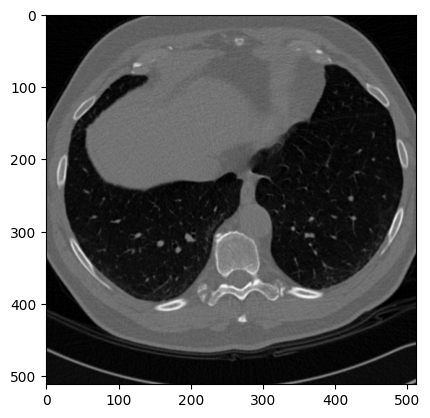

In [14]:
#Este lee tanto el .mhd y el .raw
scan = sitk.ReadImage(
 "data/subset8/1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222365663678666836860.mhd"
)
#Este convierte el CT a NumPy
image = sitk.GetArrayFromImage(scan)
#Este imprime (slices,alto,ancho)
print(image.shape)
#Este selleciona el slice 50 y lo dibuja -> con los dos comandos de abajo veo un slice pero es una sola tomografia
plt.imshow(image[70], cmap='gray')
plt.show()

# Info del Scan

In [ ]:
#Enteder el rango de HU 
print(image.min())
print(image.max())
#Tipo de dato de voxel
print(image.dtype)
#El primer dato del shape #slice,alto,ancho
print(image.shape[0])

-1024
3071
int16
194


# Ver anotaciones

In [7]:
annotations = pd.read_csv("data/annotations.csv")
annotations.head()

,seriesuid,coordX,coordY,coordZ,diameter_mm
0,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,-128.699421,-175.319272,-298.387506,5.651471
1,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,103.783651,-211.925149,-227.121250,4.224708
2,1.3.6.1.4.1.14519.5.2.1.6279.6001.100398138793...,69.639017,-140.944586,876.374496,5.786348
3,1.3.6.1.4.1.14519.5.2.1.6279.6001.100621383016...,-24.013824,192.102405,-391.081276,8.143262
4,1.3.6.1.4.1.14519.5.2.1.6279.6001.100621383016...,2.441547,172.464881,-405.493732,18.545150


# Buscar CT automáticamente

In [21]:
#solo la columna seriesuid de mi csv [4] es el número de fila
seriesuid = annotations.iloc[34]['seriesuid']
found_path = None
#recorre todos mis subset para encontrar el q es
for subset in range(10):
    #construir la ruta
    folder = f"data/subset{subset}"
    #recorre los archivos
    for file in os.listdir(folder):
        #Para buscar coincidencias y decir este es 
        if file.startswith(seriesuid):
            found_path = os.path.join(folder, file)
            break
    if found_path:
        break
print(found_path)

data/subset5\1.3.6.1.4.1.14519.5.2.1.6279.6001.112740418331256326754121315800.mhd


# Abrir Scan que encontro 

(149, 512, 512)


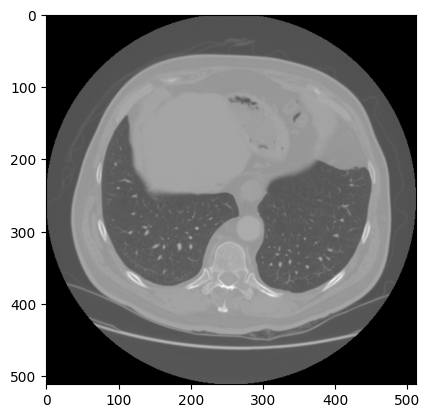

In [ ]:
scan = sitk.ReadImage(found_path)
image = sitk.GetArrayFromImage(scan)
print(image.shape)
plt.imshow(image[50], cmap='gray')
plt.show()

In [ ]:
#Donde empieza el CT ejex ejey y ejez
origin = scan.GetOrigin()
print(origin)
#tamaño del voxel
spacing = scan.GetSpacing()
print(spacing)

(-212.899994, -218.600006, -383.75)
(0.78125, 0.78125, 2.5)


# Este encuentra el slice

-99.89039388
113


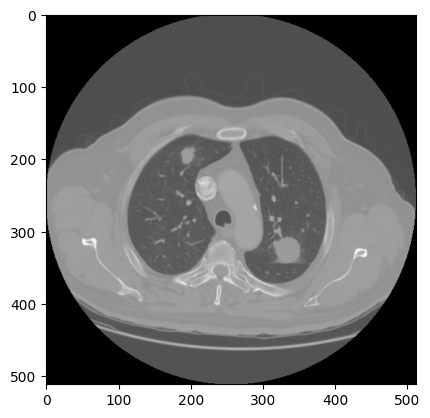

In [ ]:
#este pa tomar la fila, imprime la coordenada Z de ese fila 
coordZ = annotations.iloc[34]['coordZ']
print(coordZ)
#Donde empieza mi CT
origin = scan.GetOrigin()
#Cuanto mide el voxel
spacing = scan.GetSpacing()
slice_index = int((coordZ - origin[2]) / spacing[2])
print(slice_index)
plt.imshow(image[slice_index], cmap='gray')
plt.show()

# Este encuentra el nodulo

333 327


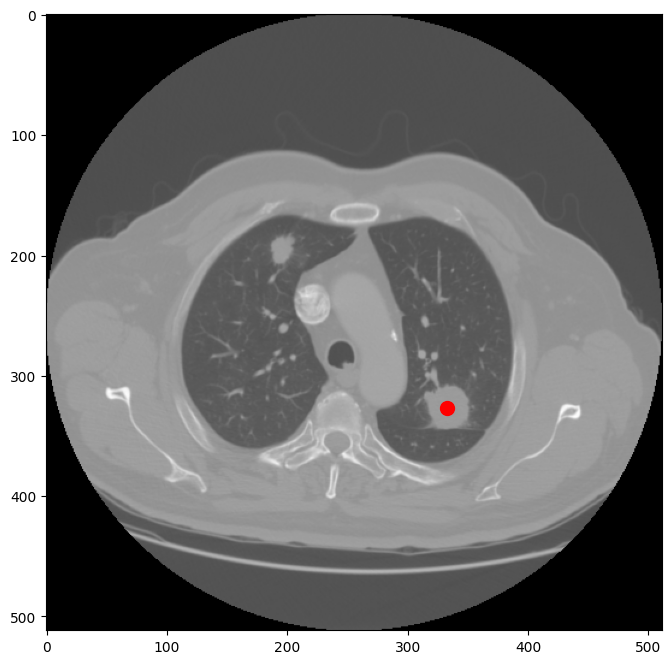

In [ ]:
coordX = annotations.iloc[34]['coordX']
coordY = annotations.iloc[34]['coordY']
#Convierte la coordenada
pixelX = int((coordX - origin[0]) / spacing[0])
pixelY = int((coordY - origin[1]) / spacing[1])
print(pixelX, pixelY)
plt.figure(figsize=(8,8))
plt.imshow(image[slice_index], cmap='gray')
#Marca centro delnodulo s=tamaño de punto rojo
plt.scatter(pixelX, pixelY, color='red', s=100)
plt.show()

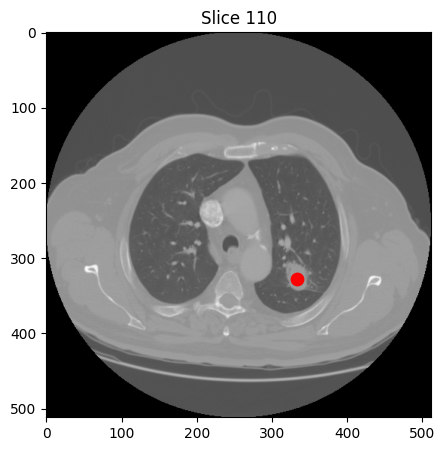

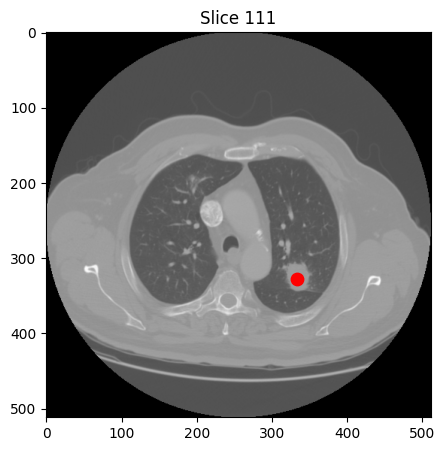

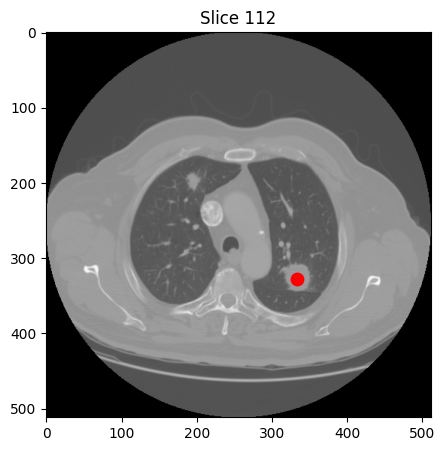

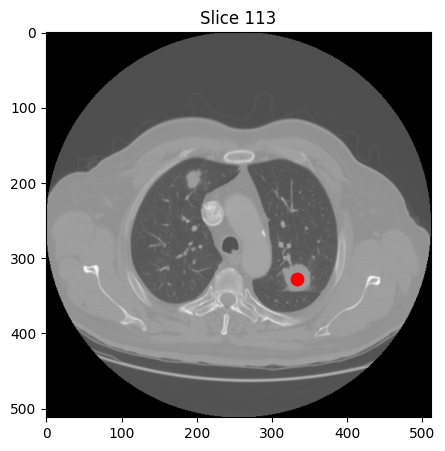

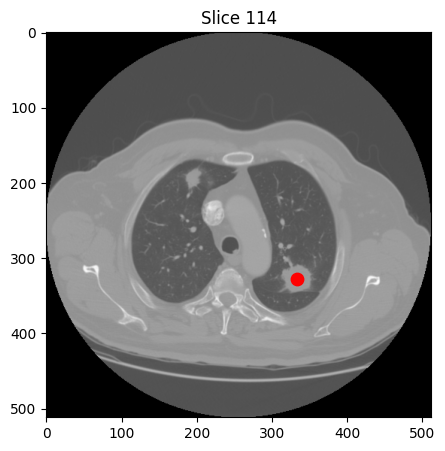

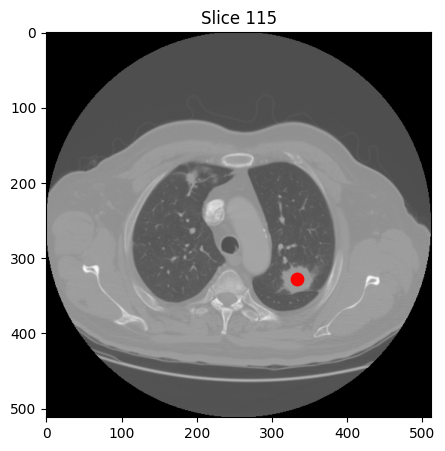

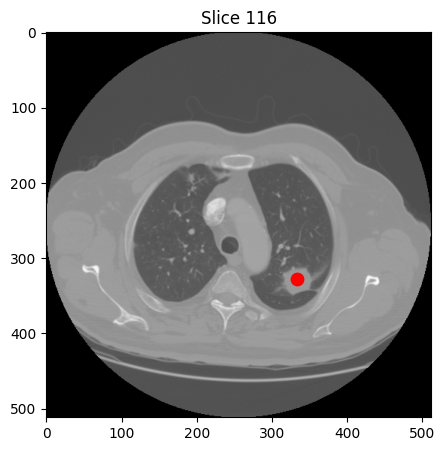

In [ ]:
for i in range(slice_index - 3, slice_index + 4):
    plt.figure(figsize=(5,5))
    plt.imshow(image[i], cmap='gray')
    plt.title(f"Slice {i}")
    plt.scatter(pixelX, pixelY, color='red', s=80)
    plt.show()

# EDA

In [ ]:
#numero de filas y numero de columnas
print(annotations.shape)

(1186, 5)


In [ ]:
# El non-null significa que no hay datos vacios 
annotations.info()

<class 'pandas.DataFrame'>
RangeIndex: 1186 entries, 0 to 1185
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   seriesuid    1186 non-null   str    
 1   coordX       1186 non-null   float64
 2   coordY       1186 non-null   float64
 3   coordZ       1186 non-null   float64
 4   diameter_mm  1186 non-null   float64
dtypes: float64(4), str(1)
memory usage: 46.5 KB


In [35]:
annotations.describe()

,coordX,coordY,coordZ,diameter_mm
count,1186.000000,1186.000000,1186.000000,1186.000000
mean,-5.067547,8.428113,-160.159029,8.306527
std,84.468115,98.316003,279.829437,4.762033
min,-164.351031,-283.834336,-790.074799,3.253443
25%,-80.909225,-51.549643,-221.197808,5.107177
50%,-32.855132,18.787926,-167.615160,6.433600
75%,76.830069,67.245915,-109.735281,9.696301
max,164.763985,271.405521,1790.494057,32.270030


<Axes: >

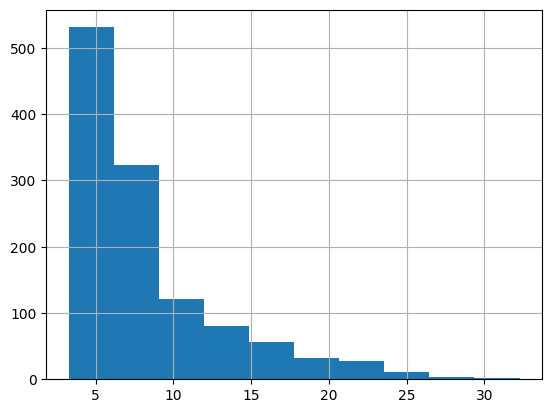

In [40]:
annotations['diameter_mm'].hist()

# Revisar CT corruptos

In [ ]:
corruptos = []
for subset in range(10):
    folder = f"data/subset{subset}"
    for file in os.listdir(folder):
        if file.endswith(".mhd"):
            path = os.path.join(folder, file)
            try:
                scan = sitk.ReadImage(path)
            except:
                corruptos.append(path)
print("Scans corruptos:", len(corruptos))

Scans corruptos: 0


# Clipping / Windowing

In [ ]:
#función para reutilizar cada q hay CT  Valores según recomendación
def preprocess_ct_scan(scan_path, hu_min=-1000, hu_max=400):
    sitk_image = sitk.ReadImage(scan_path)
    hu_array = sitk.GetArrayFromImage(sitk_image)
    #pa recortar valores que se pasan osea si hay -3000 va ser el -1000
    clipped = np.clip(hu_array, hu_min, hu_max)
    #Aparte de los valores recomendados se tiene q hacer ma chiquito osea 1 o 0 
    normalized = (clipped - hu_min) / (hu_max - hu_min)
    #tmb el float64 a 32 para consumir menos 
    normalized = normalized.astype(np.float32)
    return normalized, hu_array

In [ ]:
seriesuid = annotations.iloc[34]['seriesuid']
found_path = None
for root, dirs, files in os.walk("data"): 
    for file in files:
        if file.startswith(seriesuid) and file.endswith(".mhd"):
            found_path = os.path.join(root, file)
            break
    if found_path:
        break
if found_path:
    print("Encontrado:", found_path)
else:
    print("No se encontró el archivo para seriesuid:", seriesuid)

Encontrado: data\subset5\1.3.6.1.4.1.14519.5.2.1.6279.6001.112740418331256326754121315800.mhd


In [ ]:
scan_norm, scan_hu = preprocess_ct_scan(found_path) 
print("Forma del scan normalizado:", scan_norm.shape)
print("Rango de valores normalizados: min={:.3f}, max={:.3f}".format(scan_norm.min(), scan_norm.max()))
print("Tipo de dato:", scan_norm.dtype)

Forma del scan normalizado: (149, 512, 512)
Rango de valores normalizados: min=0.000, max=1.000
Tipo de dato: float32


Total de slices: 149


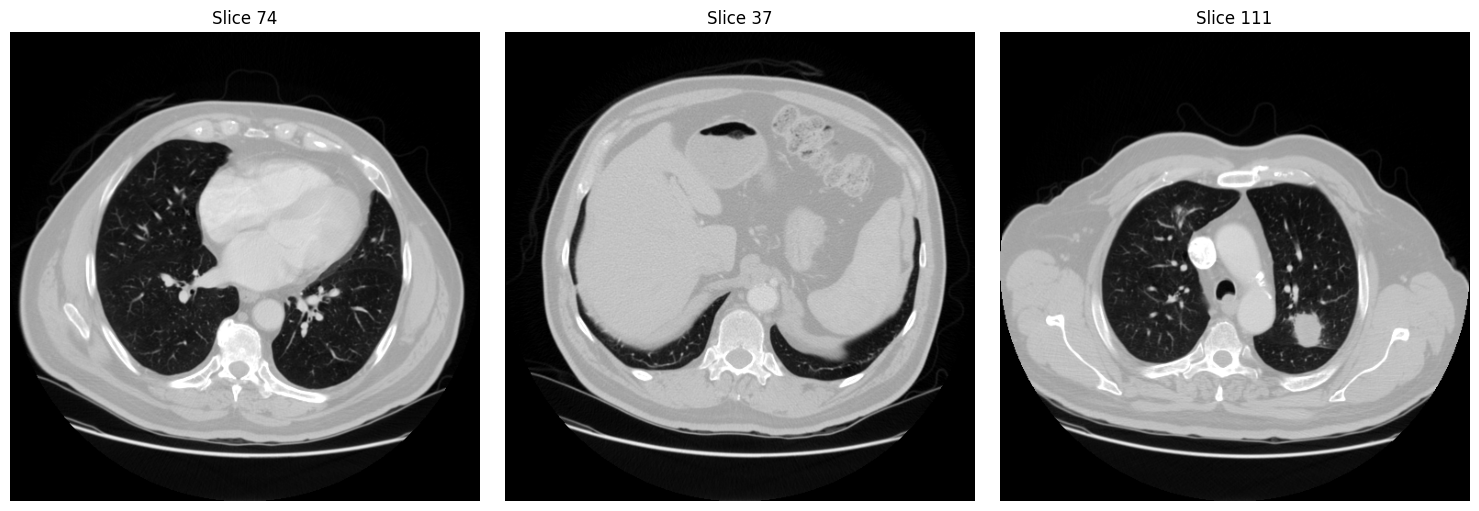

In [ ]:
num_slices = scan_norm.shape[0]
print(f"Total de slices: {num_slices}")
slices_to_show = [num_slices//2, num_slices//4, 3*num_slices//4]
#tamaño de figura
plt.figure(figsize=(15, 5))
#recorre los slice para poder mostrar los q calculamos arriba 
for i, idx in enumerate(slices_to_show):
    #una fila 3 columnas
    plt.subplot(1, 3, i+1)
    plt.imshow(scan_norm[idx], cmap='gray')
    plt.title(f"Slice {idx}")
    plt.axis('off')
plt.tight_layout()
plt.show()

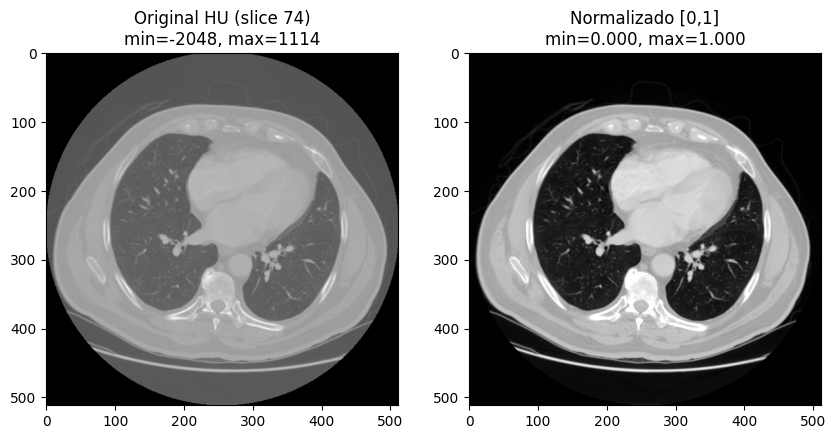

In [ ]:
idx = num_slices // 2
#grafico lado a lado
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,5))
ax1.imshow(scan_hu[idx], cmap='gray')
ax1.set_title(f"Original HU (slice {idx})\nmin={scan_hu[idx].min():.0f}, max={scan_hu[idx].max():.0f}")
ax2.imshow(scan_norm[idx], cmap='gray')
ax2.set_title(f"Normalizado [0,1]\nmin={scan_norm[idx].min():.3f}, max={scan_norm[idx].max():.3f}")
plt.show()

In [ ]:
#valido pa ver si todo cambio bonito o no 
print("HU original min:", scan_hu.min(), "max:", scan_hu.max())
clipped_test = np.clip(scan_hu, -1000, 400)
print("Después clipping min:", clipped_test.min(), "max:", clipped_test.max())
print("Normalizado min:", scan_norm.min(), "max:", scan_norm.max())

HU original min: -2048 max: 3071
Después clipping min: -1000 max: 400
Normalizado min: 0.0 max: 1.0


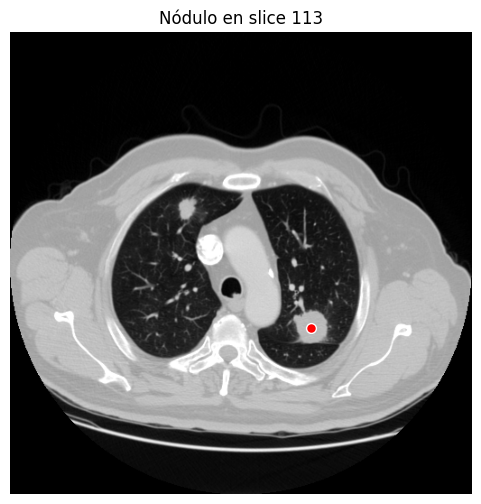

In [ ]:
plt.figure(figsize=(6,6))
plt.imshow(scan_norm[slice_index], cmap='gray')
plt.scatter(pixelX, pixelY, color='red', s=50, marker='o', edgecolors='white')
plt.title(f"Nódulo en slice {slice_index}")
plt.axis('off')
plt.show()